In [1]:
# Imports & logging
from pathlib import Path
import numpy as np
import os
from mne import grand_average
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
sys.path.append(os.path.abspath("/mount/NAS-workspace-portal/eeg2025-Vistec/"))

from eegkit.utils.system.logging_utils import configure_logging, silence_console_logs
from eegkit.models.subject_model import EEGSubjectModel
from eegkit.controller.eeg_controller import EEGController
from eegkit.models.dtos import TaskDTO, SubjectFilterDTO
from eegkit.models.dtos import EvokedParamsDTO
from eegkit.utils.channels import prepare_channels

configure_logging('INFO')
silence_console_logs('WARNING')

### Setup

In [2]:
DATA_DIR = Path(os.getenv("DATA_DIR") or os.getenv("EEG_DATA_DIR") or "")
if not DATA_DIR or not DATA_DIR.exists():
    raise FileNotFoundError("Set DATA_DIR to your BIDS root containing cmi_bids_R*/ directories.")

subject_model = EEGSubjectModel(DATA_DIR)
controller = EEGController(subject_model)

In [3]:
# Parameters: subjects, channels, and evoked window
N_SUBJECTS = 500  # use first N subjects
CHANNELS = "69-76,81-83,88,89"  # explicit posterior channels

# Evoked feature extraction params ([-2, 0] s)
params = EvokedParamsDTO(
    tmin=-2.0,
    tmax=0.0,
    stimulus=[None],
    channels=CHANNELS,
    notch=None,
    uv_min=None,
    uv_max=None,
    clean_flatline_sec=None,
    clean_hf_noise_sd_max=None,
    clean_corr_min=None,
    clean_asr_max_std=None,
    clean_power_min_sd=None,
    clean_power_max_sd=None,
    clean_max_outbound_pct=None,
    clean_window_sec=None,
    spatial_colors=True,
    average_line=True,
)
print(f"Subjects: {N_SUBJECTS}, Channels: {CHANNELS}")

Subjects: 500, Channels: 69-76,81-83,88,89


### Load

In [4]:
group_dto = SubjectFilterDTO(task='contrastChangeDetection', subject_limit=N_SUBJECTS)
all_task_dtos = subject_model.get_filter_subjects_dto(group_dto)

seen = set()
selected_dtos = []
for dto in all_task_dtos:
    if dto.subject in seen:
        continue
    seen.add(dto.subject)
    selected_dtos.append(dto)
    if len(selected_dtos) >= N_SUBJECTS:
        break

selected_subjects = [d.subject for d in selected_dtos]
print(f"Selected subjects ({len(selected_subjects)}):", selected_subjects[:10])

Selected subjects (500): ['sub-NDARAA948VFH', 'sub-NDARAB678VYW', 'sub-NDARAB793GL3', 'sub-NDARAC904DMU', 'sub-NDARAD774HAZ', 'sub-NDARAE828CML', 'sub-NDARAG143ARJ', 'sub-NDARAG340ERT', 'sub-NDARAG788YV9', 'sub-NDARAK770XEW']


In [5]:
evk_list, ok_subjects = [], []
task_name = 'contrastChangeDetection'

for subj in selected_subjects:
    subj_tasks = subject_model.list_tasks(subj)
    runs = [r for (t, r) in subj_tasks if t == task_name] or [None]

    evks = []
    for run in runs:
        dto = TaskDTO(subject=subj, task=task_name, run=run)
        evk = controller.get_evoked(dto, params)
        if evk is None:
            continue
        evks.append(prepare_channels(evk, params))

    if not evks:
        continue

    evk_avg = evks[0] if len(evks) == 1 else grand_average(evks)
    evk_list.append(evk_avg)
    ok_subjects.append(subj)

df_meta = subject_model.get_subjects_metadata(ok_subjects, columns=['ccd_accuracy','ccd_response_time'])
df_meta = df_meta.set_index('participant_id').loc[ok_subjects]
y_df = df_meta[['ccd_accuracy','ccd_response_time']].copy()
y = y_df.astype(float).values

## model

### EEGNetMultiReg Configuration (NN Version)

Input:
- 500 subjects
- 2-second ITI CCD evoked responses
- Channels: 69–76, 81–83, 88, 89

Data split:
- Train/Validation/Test split: 350 / 75 / 75 subjects (from 500 total)

Target modeling strategy:
- A single multi-output neural network model (`EEGNetMultiReg`) was trained to jointly predict both ACC and RT.

Model pipeline:
- Per-subject channel-wise normalization across time
- EEGNet-style convolutional backbone (`Conv2d + BatchNorm + ELU + Dropout + MaxPool`)
- Final regression head: `LazyLinear(2)` for simultaneous ACC and RT prediction

Model advantages:
- **Nonlinear feature extraction:** Convolutional blocks capture complex spatial-temporal relationships in EEG without manual feature engineering.
- **Multi-task learning:** Shared CNN backbone enables joint optimization of ACC and RT, leveraging their correlated structure and improving generalization.
- **End-to-end learning:** Single unified model with one forward pass ensures consistent, efficient inference and learned feature representations optimized jointly for both targets.

Validation strategy:
- Hold-out validation split with early stopping (patience = 20, max epochs = 500)
- No GroupKFold cross-validation in this NN setup

Training objective and evaluation:
- Training loss: Mean Squared Error (MSE) on standardized targets
- Optimizer: Adam (`lr=1e-3`, `weight_decay=1e-4`)
- Test metrics: Mean Absolute Error (MAE) and Pearson correlation for ACC and RT

In [13]:
from torchinfo import summary
summary(model, input_size=X.shape)

Layer (type:depth-idx)                   Output Shape              Param #
EEGNetMultiReg                           [500, 2]                  --
├─Conv2d: 1-1                            [500, 16, 13, 138]        1,040
├─BatchNorm2d: 1-2                       [500, 16, 13, 138]        --
├─ZeroPad2d: 1-3                         [500, 16, 14, 171]        --
├─Conv2d: 1-4                            [500, 32, 13, 140]        32,800
├─BatchNorm2d: 1-5                       [500, 32, 13, 140]        --
├─MaxPool2d: 1-6                         [500, 32, 6, 35]          --
├─ZeroPad2d: 1-7                         [500, 32, 13, 38]         --
├─Conv2d: 1-8                            [500, 64, 6, 35]          65,600
├─BatchNorm2d: 1-9                       [500, 64, 6, 35]          --
├─MaxPool2d: 1-10                        [500, 64, 3, 8]           --
├─Linear: 1-11                           [500, 2]                  3,074
Total params: 102,514
Trainable params: 102,514
Non-trainable params: 0

In [6]:
class EEGNetMultiReg(nn.Module):
    """EEGNet variant producing continuous outputs for regression tasks."""

    DISPLAY_NAME = "EEGNet (multi-regression)"
    DESCRIPTION = (
        "EEGNet variant with a shared convolutional trunk and one LazyLinear head "
        "emitting N continuous regression targets (e.g., ccd_accuracy, ccd_response_time)."
    )

    def __init__(self, n_outputs: int = 1):
        """Initialize shared CNN trunk and a single regression head."""
        super().__init__()
        self.n_outputs = int(n_outputs)

        self.conv1 = nn.Conv2d(1, 16, (1, 64))
        self.batchnorm1 = nn.BatchNorm2d(16, affine=False)

        self.padding1 = nn.ZeroPad2d((16, 17, 0, 1))
        self.conv2 = nn.Conv2d(16, 32, (2, 32))
        self.batchnorm2 = nn.BatchNorm2d(32, affine=False)
        self.pooling2 = nn.MaxPool2d((2, 4))

        self.padding2 = nn.ZeroPad2d((2, 1, 4, 3))
        self.conv3 = nn.Conv2d(32, 64, (8, 4))
        self.batchnorm3 = nn.BatchNorm2d(64, affine=False)
        self.pooling3 = nn.MaxPool2d((2, 4))

        # Regression head (LazyLinear infers in_features after first forward pass)
        self.fc_reg = nn.LazyLinear(self.n_outputs)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return continuous predictions with shape (batch_size, n_outputs)."""
        if x.ndim == 3:  # (batch, channels, time)
            x = x.unsqueeze(1)  # add spatial dim for conv2d trunk

        x = F.elu(self.conv1(x))
        x = self.batchnorm1(x)
        x = F.dropout(x, 0.25)

        x = self.padding1(x)
        x = F.elu(self.conv2(x))
        x = self.batchnorm2(x)
        x = F.dropout(x, 0.25)
        x = self.pooling2(x)

        x = self.padding2(x)
        x = F.elu(self.conv3(x))
        x = self.batchnorm3(x)
        x = F.dropout(x, 0.25)
        x = self.pooling3(x)

        x = torch.flatten(x, start_dim=1)
        return self.fc_reg(x)

## Train
Build a fixed-shape tensor dataset from per-subject evoked averages, then train EEGNet for multi-target regression (ACC, RT).

In [7]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def evoked_to_fixed_array(evk, ref_ch_names, ref_times):
    """Convert an Evoked to a fixed (n_ch, n_times) float32 array."""
    ref_ch_to_idx = {ch: i for i, ch in enumerate(ref_ch_names)}
    out = np.zeros((len(ref_ch_names), len(ref_times)), dtype=np.float32)

    # Interpolate along time if needed
    src_times = evk.times.astype(float)
    src_data = evk.data.astype(np.float32, copy=False)
    if src_data.shape[1] != len(ref_times) or not np.allclose(src_times, ref_times, atol=1e-9, rtol=0.0):
        interp = np.empty((src_data.shape[0], len(ref_times)), dtype=np.float32)
        for ci in range(src_data.shape[0]):
            interp[ci] = np.interp(ref_times, src_times, src_data[ci]).astype(np.float32)
        src_data = interp

    # Map channels into the reference layout; missing channels stay 0
    for src_i, ch in enumerate(evk.ch_names):
        dst_i = ref_ch_to_idx.get(ch)
        if dst_i is None:
            continue
        out[dst_i] = src_data[src_i]

    return out

# Build X (subjects x channels x time) with a stable channel/time layout
if not evk_list:
    raise RuntimeError('evk_list is empty. Run the Load cell first.')
ref_ch_names = list(evk_list[0].ch_names)
ref_times = evk_list[0].times.astype(float)

X_list = []
keep_idx = []
for i, evk in enumerate(evk_list):
    arr = evoked_to_fixed_array(evk, ref_ch_names=ref_ch_names, ref_times=ref_times)
    if not np.isfinite(arr).any():
        continue
    # Per-subject, per-channel normalization across time
    mean = arr.mean(axis=1, keepdims=True)
    std = arr.std(axis=1, keepdims=True) + 1e-6
    arr = (arr - mean) / std
    X_list.append(arr)
    keep_idx.append(i)

X = np.stack(X_list, axis=0).astype(np.float32)
y = np.asarray(y, dtype=np.float32)[keep_idx]
ok_subjects = [ok_subjects[i] for i in keep_idx]
print('X:', X.shape, 'y:', y.shape, 'subjects:', len(ok_subjects))

X: (500, 13, 201) y: (500, 2) subjects: 500


In [8]:
# Train/val/test split
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42
)

# Standardize targets using train stats (helps NN stability)
y_mean = y_train.mean(axis=0, keepdims=True)
y_std = y_train.std(axis=0, keepdims=True) + 1e-6
y_train_s = (y_train - y_mean) / y_std
y_val_s = (y_val - y_mean) / y_std
y_test_s = (y_test - y_mean) / y_std

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (350, 13, 201) (350, 2)
Val  : (75, 13, 201) (75, 2)
Test : (75, 13, 201) (75, 2)


Device: cuda


/root/miniconda3/envs/py312_env/lib/python3.12/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5080 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5080 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


Epoch 001 | train 1.5856 | val 1.1697 | best 1.1697
Epoch 010 | train 0.3650 | val 0.9844 | best 0.9844
Epoch 020 | train 0.2302 | val 1.2125 | best 0.9844
Epoch 030 | train 0.2089 | val 1.0657 | best 0.9844
Early stop at epoch 30


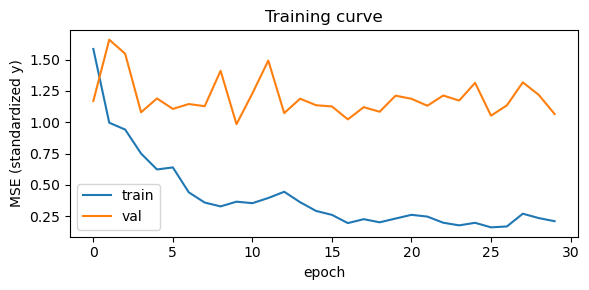

In [9]:
from torch.utils.data import DataLoader, TensorDataset

# Repro + device
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

train_ds = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train_s),
)
val_ds = TensorDataset(
    torch.from_numpy(X_val),
    torch.from_numpy(y_val_s),
)
test_ds = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(y_test_s),
)

batch_size = 8
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

model = EEGNetMultiReg(n_outputs=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

def run_epoch(loader, train=False):
    """Run one epoch and return mean loss."""
    model.train(train)
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        if train:
            optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        if train:
            loss.backward()
            optimizer.step()
        total += float(loss.item()) * xb.shape[0]
        n += xb.shape[0]
    return total / max(1, n)

# Training loop with early stopping
best_val = float('inf')
best_state = None
patience = 20
bad = 0
max_epochs = 500
history = []

for epoch in range(1, max_epochs + 1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)
    history.append((tr, va))
    if va < best_val - 1e-5:
        best_val = va
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | train {tr:.4f} | val {va:.4f} | best {best_val:.4f}')
    if bad >= patience:
        print('Early stop at epoch', epoch)
        break

if best_state is not None:
    model.load_state_dict(best_state)

# Plot loss curves
tr_hist = [h[0] for h in history]
va_hist = [h[1] for h in history]
plt.figure(figsize=(6, 3))
plt.plot(tr_hist, label='train')
plt.plot(va_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('MSE (standardized y)')
plt.title('Training curve')
plt.legend()
plt.tight_layout()
plt.show()

Test ACC: corr= 0.24331807914183057 MAE= 17.07118034362793
Test RT : corr= 0.08898265968876973 MAE= 0.2023548185825348


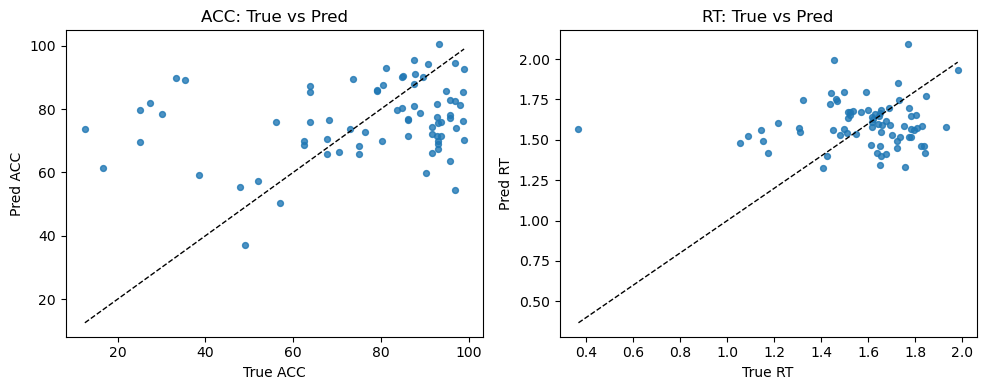

In [10]:
# Evaluate + plot True vs Pred on test
model.eval()
pred_list = []
true_list = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        pred_list.append(pred)
        true_list.append(yb.cpu().numpy())
y_pred_s = np.vstack(pred_list)
y_true_s = np.vstack(true_list)

# Unstandardize
y_pred = y_pred_s * y_std + y_mean
y_true = y_true_s * y_std + y_mean

def corr(a, b):
    if len(a) < 2:
        return float('nan')
    return float(np.corrcoef(a, b)[0, 1])

mae_acc = float(np.mean(np.abs(y_true[:, 0] - y_pred[:, 0])))
mae_rt = float(np.mean(np.abs(y_true[:, 1] - y_pred[:, 1])))
corr_acc = corr(y_true[:, 0], y_pred[:, 0])
corr_rt = corr(y_true[:, 1], y_pred[:, 1])
print('Test ACC: corr=', corr_acc, 'MAE=', mae_acc)
print('Test RT : corr=', corr_rt,  'MAE=', mae_rt)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(y_true[:, 0], y_pred[:, 0], s=18, alpha=0.8)
lo, hi = np.min(y_true[:, 0]), np.max(y_true[:, 0])
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[0].set_xlabel('True ACC')
axes[0].set_ylabel('Pred ACC')
axes[0].set_title('ACC: True vs Pred')

axes[1].scatter(y_true[:, 1], y_pred[:, 1], s=18, alpha=0.8)
lo, hi = np.min(y_true[:, 1]), np.max(y_true[:, 1])
axes[1].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[1].set_xlabel('True RT')
axes[1].set_ylabel('Pred RT')
axes[1].set_title('RT: True vs Pred')

plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import r2_score

# R2
r2_acc = r2_score(y_true[:, 0], y_pred[:, 0])
r2_rt  = r2_score(y_true[:, 1], y_pred[:, 1])

# Baseline MAE (mean predictor on test set)
baseline_acc = np.mean(np.abs(y_true[:, 0] - np.mean(y_true[:, 0])))
baseline_rt  = np.mean(np.abs(y_true[:, 1] - np.mean(y_true[:, 1])))

print("ACC -> MAE:", mae_acc, "Baseline:", baseline_acc, "R2:", r2_acc, "Corr:", corr_acc)
print("RT  -> MAE:", mae_rt,  "Baseline:", baseline_rt,  "R2:", r2_rt,  "Corr:", corr_rt)


ACC -> MAE: 17.07118034362793 Baseline: 17.965117 R2: -0.014806032180786133 Corr: 0.24331807914183057
RT  -> MAE: 0.2023548185825348 Baseline: 0.1716642 R2: -0.2490372657775879 Corr: 0.08898265968876973
